Práctico 1 — Análisis exploratorio y visualización

1. Descripción general del dataset
¿Cuántos registros y variables tiene cada archivo? ¿Qué tipo de variables hay (numéricas, categóricas)?
¿Qué representa cada archivo y cómo se relacionan entre sí?

In [1]:
# Cargamos las librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
# Cargamos los datos desde la URL del repositorio

df1 = r"https://github.com/carolinapepe/diplodatos-ai-impact-workforce/blob/main/data/raw/ai_company_adoption.csv"
df2 = r"https://github.com/carolinapepe/diplodatos-ai-impact-workforce/blob/main/data/raw/ai_industry_summary.csv"
df3 = r"https://github.com/carolinapepe/diplodatos-ai-impact-workforce/blob/main/data/raw/country_ai_index.csv"


In [3]:
# Exploramos los registros y variables de cada dataset
# Se corrigen las URLs para apuntar al contenido "raw" de los archivos en GitHub.
df1_url = r"https://raw.githubusercontent.com/carolinapepe/diplodatos-ai-impact-workforce/main/data/raw/ai_company_adoption.csv"
df2_url = r"https://raw.githubusercontent.com/carolinapepe/diplodatos-ai-impact-workforce/main/data/raw/ai_industry_summary.csv"
df3_url = r"https://raw.githubusercontent.com/carolinapepe/diplodatos-ai-impact-workforce/main/data/raw/country_ai_index.csv"

df1 = pd.read_csv(df1_url)
df2= pd.read_csv(df2_url)
df3 = pd.read_csv(df3_url)

In [4]:
print(f"Shape of df1: {df1.shape}")
df1.info()

Shape of df1: (150025, 43)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150025 entries, 0 to 150024
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   response_id                  150025 non-null  int64  
 1   company_id                   150025 non-null  object 
 2   survey_year                  150024 non-null  float64
 3   quarter                      150025 non-null  object 
 4   country                      150024 non-null  object 
 5   region                       150024 non-null  object 
 6   industry                     147772 non-null  object 
 7   company_size                 147774 non-null  object 
 8   num_employees                150025 non-null  float64
 9   annual_revenue_usd_millions  147778 non-null  float64
 10  company_founding_year        150025 non-null  float64
 11  company_age                  150025 non-null  float64
 12  company_age_group            15

AI_company_adoption es un dataset con encuestas trimestrales que se realizaron a un total de 10mil empresas. En la encuesta se recolectan datos sobre variables de adopcion y gasto en IA, variables economicas y de productividad y caracteristicas propias de las empresas

In [5]:
print(f"Shape of df2: {df2.shape}")
df2.info()

Shape of df2: (9, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   industry                         9 non-null      object 
 1   avg_ai_adoption_rate             9 non-null      float64
 2   avg_productivity_change_percent  9 non-null      float64
 3   avg_ai_maturity_score            9 non-null      float64
 4   avg_ai_failure_rate              9 non-null      float64
 5   avg_jobs_displaced               9 non-null      float64
 6   avg_jobs_created                 9 non-null      float64
 7   avg_customer_satisfaction        9 non-null      float64
dtypes: float64(7), object(1)
memory usage: 708.0+ bytes


ai_industry_summary es un dataset que recopila promedios de variables relacionadas a la adopcion de la IA, creacion/desplazo de empleos y cambios en la productividad y satisfacccion del cliente.

In [6]:
print(f"Shape of df3: {df3.shape}")
df3.info()

Shape of df3: (30, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country                     30 non-null     object 
 1   region                      30 non-null     object 
 2   gdp_per_capita              30 non-null     float64
 3   internet_penetration        30 non-null     float64
 4   digital_maturity_index      30 non-null     float64
 5   country_ai_policy           30 non-null     object 
 6   ai_patent_filings_2024      30 non-null     int64  
 7   ai_researchers_per_million  30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


country_ai_index es un dataset con la lista de paises de los cuales provenienen las empresas participantes de la encuesta. En este dataset se recopilan variables económicas y datos de adopción y regulación de IA de cada País.


AI_company_adoption es el principal dataset ya que contiene todos los datos que se recolectaron de las encuestas. Se relaciona entre si con los otros dataset ya que contienen informacion adicional sobre los paises y las industrias.

#Creamos un diccionario de datos para organizar las variables del dataset

In [7]:
# Diccionario de datos: variable, dataframe, tipo analitico y descripcion breve
# tipo analitico: identificador | temporal | numerica_continua | numerica_discreta |
#                 categorica_nominal | categorica_ordinal

diccionario_df1 = pd.DataFrame([
    ("response_id", "identificador", "Identificador unico de cada respuesta de encuesta"),
    ("company_id", "identificador", "Identificador unico de empresa (se repite entre trimestres)"),
    ("survey_year", "temporal", "Anio de la encuesta (2023-2026)"),
    ("quarter", "categorica_ordinal", "Trimestre de la encuesta (Q1 a Q4, orden natural dentro del anio)"),
    ("country", "categorica_nominal", "Pais de la empresa"),
    ("region", "categorica_nominal", "Region geografica de la empresa"),
    ("industry", "categorica_nominal", "Rubro/industria de la empresa"),
    ("company_size", "categorica_ordinal", "Tamanio de la empresa (Startup < SME < Enterprise)"),
    ("num_employees", "numerica_discreta", "Cantidad de empleados de la empresa"),
    ("annual_revenue_usd_millions", "numerica_continua", "Ingresos anuales de la empresa (millones USD)"),
    ("company_founding_year", "temporal", "Anio de fundacion de la empresa"),
    ("company_age", "numerica_discreta", "Antiguedad de la empresa en anios"),
    ("company_age_group", "categorica_ordinal", "Antiguedad agrupada (0-5 < 6-15 < 16-30 < 30+ anios)"),
    ("ai_adoption_rate", "numerica_continua", "Porcentaje de adopcion de IA declarado"),
    ("ai_adoption_stage", "categorica_ordinal", "Etapa de adopcion (none < pilot < partial < full)"),
    ("years_using_ai", "numerica_discreta", "Anios que la empresa lleva usando IA"),
    ("ai_primary_tool", "categorica_nominal", "Herramienta de IA principal utilizada"),
    ("num_ai_tools_used", "numerica_discreta", "Cantidad de herramientas de IA en uso"),
    ("ai_use_case", "categorica_nominal", "Caso de uso principal de la IA en la empresa"),
    ("ai_projects_active", "numerica_discreta", "Cantidad de proyectos de IA activos"),
    ("ai_training_hours", "numerica_continua", "Horas de capacitacion en IA por empleado"),
    ("ai_budget_percentage", "numerica_continua", "Porcentaje del presupuesto destinado a IA"),
    ("ai_maturity_score", "numerica_continua", "Puntaje de madurez de IA de la empresa"),
    ("ai_failure_rate", "numerica_continua", "Tasa de fallas de proyectos de IA"),
    ("ai_investment_per_employee", "numerica_continua", "Inversion en IA por empleado (USD)"),
    ("regulatory_compliance_score", "numerica_continua", "Puntaje de cumplimiento regulatorio"),
    ("data_privacy_level", "categorica_ordinal", "Nivel de privacidad de datos (Low < Medium < High)"),
    ("ai_ethics_committee", "categorica_nominal", "Si la empresa tiene comite de etica de IA (Yes/No)"),
    ("ai_risk_management_score", "numerica_continua", "Puntaje de gestion de riesgo de IA"),
    ("remote_work_percentage", "numerica_continua", "Porcentaje de trabajo remoto en la empresa"),
    ("employee_satisfaction_score", "numerica_continua", "Puntaje de satisfaccion de empleados"),
    ("task_automation_rate", "numerica_continua", "Porcentaje de tareas automatizadas"),
    ("time_saved_per_week", "numerica_continua", "Horas ahorradas por semana gracias a la IA"),
    ("productivity_change_percent", "numerica_continua", "Cambio porcentual en productividad"),
    ("jobs_displaced", "numerica_discreta", "Cantidad de empleos desplazados por IA"),
    ("jobs_created", "numerica_discreta", "Cantidad de empleos creados por IA"),
    ("reskilled_employees", "numerica_discreta", "Cantidad de empleados reentrenados"),
    ("revenue_growth_percent", "numerica_continua", "Crecimiento porcentual de ingresos"),
    ("cost_reduction_percent", "numerica_continua", "Reduccion porcentual de costos"),
    ("innovation_score", "numerica_continua", "Puntaje de innovacion"),
    ("customer_satisfaction", "numerica_continua", "Puntaje de satisfaccion del cliente"),
    ("survey_source", "categorica_nominal", "Fuente/entidad que realizo la encuesta"),
    ("data_collection_method", "categorica_nominal", "Metodo de recoleccion de datos"),
], columns=["variable", "tipo_analitico", "descripcion"])
diccionario_df1["dataframe"] = "df1 (ai_company_adoption)"
grupos_tematicos = {
    "response_id": "Identificación/metadata", "company_id": "Identificación/metadata",
    "survey_year": "Identificación/metadata", "quarter": "Identificación/metadata",
    "survey_source": "Identificación/metadata", "data_collection_method": "Identificación/metadata",
    "country": "Contexto geográfico/sectorial", "region": "Contexto geográfico/sectorial",
    "industry": "Contexto geográfico/sectorial",
    "company_size": "Características estructurales", "num_employees": "Características estructurales",
    "annual_revenue_usd_millions": "Características estructurales", "company_founding_year": "Características estructurales",
    "company_age": "Características estructurales", "company_age_group": "Características estructurales",
    "ai_adoption_rate": "Adopción de IA", "ai_adoption_stage": "Adopción de IA", "years_using_ai": "Adopción de IA",
    "ai_primary_tool": "Adopción de IA", "num_ai_tools_used": "Adopción de IA", "ai_use_case": "Adopción de IA",
    "ai_projects_active": "Adopción de IA", "ai_training_hours": "Adopción de IA",
    "ai_budget_percentage": "Adopción de IA", "ai_maturity_score": "Adopción de IA",
    "ai_investment_per_employee": "Adopción de IA",
    "ai_failure_rate": "Gobernanza y riesgo", "regulatory_compliance_score": "Gobernanza y riesgo",
    "data_privacy_level": "Gobernanza y riesgo", "ai_ethics_committee": "Gobernanza y riesgo",
    "ai_risk_management_score": "Gobernanza y riesgo",
    "remote_work_percentage": "Impacto en personas/trabajo", "employee_satisfaction_score": "Impacto en personas/trabajo",
    "task_automation_rate": "Impacto en personas/trabajo", "time_saved_per_week": "Impacto en personas/trabajo",
    "jobs_displaced": "Impacto en personas/trabajo", "jobs_created": "Impacto en personas/trabajo",
    "reskilled_employees": "Impacto en personas/trabajo",
    "productivity_change_percent": "Impacto en el negocio", "revenue_growth_percent": "Impacto en el negocio",
    "cost_reduction_percent": "Impacto en el negocio", "innovation_score": "Impacto en el negocio",
    "customer_satisfaction": "Impacto en el negocio",
}
diccionario_df1["grupo_tematico"] = diccionario_df1["variable"].map(grupos_tematicos).fillna("—")

diccionario_df2 = pd.DataFrame([
    ("industry", "categorica_nominal", "Rubro/industria (clave de agregacion)"),
    ("avg_ai_adoption_rate", "numerica_continua", "Adopcion de IA promedio de la industria"),
    ("avg_productivity_change_percent", "numerica_continua", "Cambio de productividad promedio"),
    ("avg_ai_maturity_score", "numerica_continua", "Madurez de IA promedio"),
    ("avg_ai_failure_rate", "numerica_continua", "Tasa de fallas promedio"),
    ("avg_jobs_displaced", "numerica_continua", "Empleos desplazados, promedio"),
    ("avg_jobs_created", "numerica_continua", "Empleos creados, promedio"),
    ("avg_customer_satisfaction", "numerica_continua", "Satisfaccion del cliente promedio"),
], columns=["variable", "tipo_analitico", "descripcion"])
diccionario_df2["dataframe"] = "df2 (ai_industry_summary)"

diccionario_df3 = pd.DataFrame([
    ("country", "categorica_nominal", "Pais"),
    ("region", "categorica_nominal", "Region geografica"),
    ("gdp_per_capita", "numerica_continua", "PBI per capita"),
    ("internet_penetration", "numerica_continua", "Penetracion de internet (%)"),
    ("digital_maturity_index", "numerica_continua", "Indice de madurez digital"),
    ("country_ai_policy", "categorica_ordinal", "Politica de IA del pais (Lenient < Moderate < Strict)"),
    ("ai_patent_filings_2024", "numerica_discreta", "Patentes de IA registradas en 2024"),
    ("ai_researchers_per_million", "numerica_continua", "Investigadores en IA por millon de habitantes"),
], columns=["variable", "tipo_analitico", "descripcion"])
diccionario_df3["dataframe"] = "df3 (country_ai_index)"

diccionario = pd.concat([diccionario_df1, diccionario_df2, diccionario_df3], ignore_index=True)
diccionario = diccionario[["dataframe", "variable", "tipo_analitico", "descripcion"]]
diccionario

,dataframe,variable,tipo_analitico,descripcion
0,df1 (ai_company_adoption),response_id,identificador,Identificador unico de cada respuesta de encuesta
1,df1 (ai_company_adoption),company_id,identificador,Identificador unico de empresa (se repite entr...
2,df1 (ai_company_adoption),survey_year,temporal,Anio de la encuesta (2023-2026)
3,df1 (ai_company_adoption),quarter,categorica_ordinal,"Trimestre de la encuesta (Q1 a Q4, orden natur..."
4,df1 (ai_company_adoption),country,categorica_nominal,Pais de la empresa
5,df1 (ai_company_adoption),region,categorica_nominal,Region geografica de la empresa
6,df1 (ai_company_adoption),industry,categorica_nominal,Rubro/industria de la empresa
7,df1 (ai_company_adoption),company_size,categorica_ordinal,Tamanio de la empresa (Startup < SME < Enterpr...
8,df1 (ai_company_adoption),num_employees,numerica_discreta,Cantidad de empleados de la empresa
9,df1 (ai_company_adoption),annual_revenue_usd_millions,numerica_continua,Ingresos anuales de la empresa (millones USD)


### De las 43 columnas de df1, la mayoría son numéricas (continuas o discretas), y un puñado son identificadores o variables temporales puras (response_id, company_id, survey_year) que no aportan señal analítica, solo trazabilidad.

###Entre las categóricas, la distinción nominal/ordinal importa porque define cómo graficarlas (con un orden explícito en el eje) y cómo codificarlas para un modelo (ordinal encoding vs. one-hot). Son ordinales quarter, company_size, company_age_group, ai_adoption_stage, data_privacy_level y country_ai_policy (en df3) — con dos salvedades: company_age_group es redundante con company_age (ya numérica), y quarter es ordinal solo dentro de un mismo año, no de forma global (después de Q4 vuelve a Q1).

###El resto (country, region, industry, ai_primary_tool, ai_use_case, survey_source, data_collection_method) son nominales, sin orden intrínseco. ai_ethics_committee es nominal pero binaria (Yes/No), así que ya funciona como dummy sin necesidad de one-hot.

## 2. Análisis univariado

**Nota sobre la temporalidad:** `df1` no es una foto única, es un panel de encuestas: cada empresa (`company_id`) fue encuestada varias veces a lo largo de trimestres distintos (`survey_year` + `quarter`), entre 2023 y 2026. Antes de mirar la distribución de las variables numéricas, chequeamos que las encuestas estén razonablemente balanceadas en el tiempo, si un trimestre tuviera muchas menos respuestas que otro, cualquier distribución que veamos podría estar sesgada por ese desbalance.

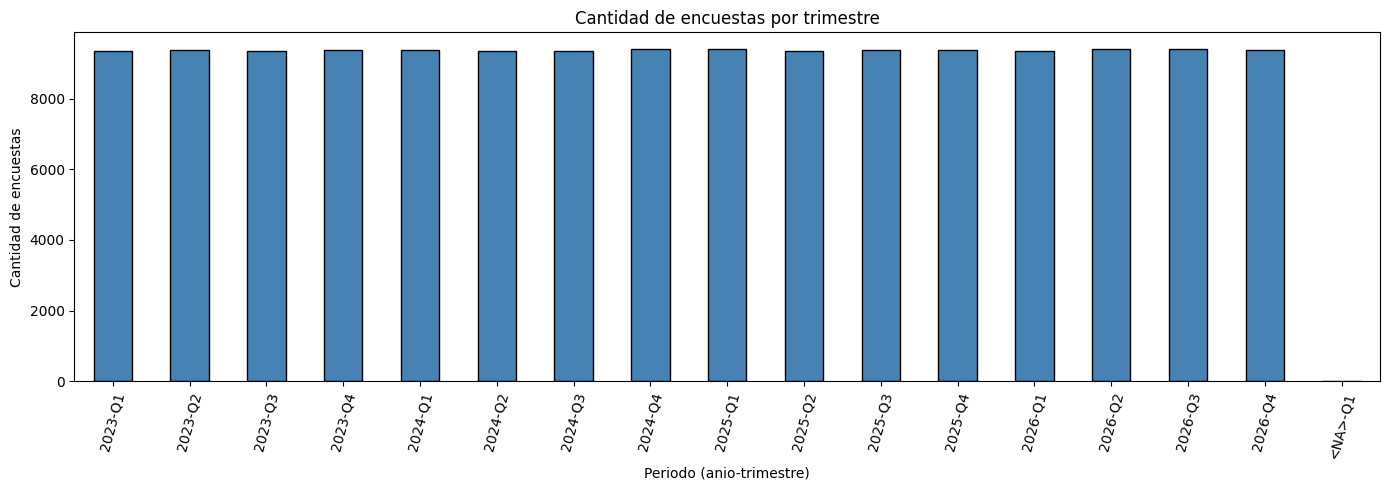

Cantidad de empresas unicas: 10025
Encuestas por empresa - min: 1, max: 16, promedio: 15.0


In [8]:
# Cantidad de encuestas por anio-trimestre, para chequear el balance temporal
df1["periodo"] = df1["survey_year"].astype("Int64").astype(str) + "-" + df1["quarter"].astype(str)
conteo_periodo = df1["periodo"].value_counts().sort_index()

plt.figure(figsize=(14, 5))
conteo_periodo.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Cantidad de encuestas por trimestre")
plt.xlabel("Periodo (anio-trimestre)")
plt.ylabel("Cantidad de encuestas")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

print(f"Cantidad de empresas unicas: {df1['company_id'].nunique()}")
print(f"Encuestas por empresa - min: {df1.groupby('company_id').size().min()}, "
      f"max: {df1.groupby('company_id').size().max()}, "
      f"promedio: {df1.groupby('company_id').size().mean():.1f}")

La distribución de las encuestas es uniforme a lo largo de todo el dataset por lo que no veremos sobre o subreporte de ningun cuatrimestre

Si bien el panel de las encuestas esta balanceado por cuatrimestre, esto no nos dice nada sobre cuanto cambian las variables a lo largo del tiempo. Para ello lo chequeamos verificando como fluctuan las variables trimestre a trimestre. Aqui el analisis se restringe a las variables que seleccionamos de interes.

In [9]:


variables_a_chequear = [
    "ai_budget_percentage", "ai_investment_per_employee",
    "productivity_change_percent", "revenue_growth_percent", "cost_reduction_percent",
    "jobs_displaced", "jobs_created", "reskilled_employees", "task_automation_rate"
]

resultados = []
for var in variables_a_chequear:
    var_total = df1[var].var()
    medias_por_empresa = df1.groupby("company_id")[var].mean()
    var_entre = medias_por_empresa.var()
    var_dentro = df1.groupby("company_id")[var].var().mean()
    pct_dentro = var_dentro / (var_dentro + var_entre) * 100
    resultados.append({
        "variable": var,
        "var_entre_empresas": round(var_entre, 2),
        "var_dentro_empresa": round(var_dentro, 2),
        "%_variacion_dentro": round(pct_dentro, 1)
    })

tabla_varianza = pd.DataFrame(resultados).sort_values("%_variacion_dentro", ascending=False)
tabla_varianza

,variable,var_entre_empresas,var_dentro_empresa,%_variacion_dentro
4,cost_reduction_percent,2.340000e+00,1.656000e+01,87.6
3,revenue_growth_percent,5.080000e+00,3.040000e+01,85.7
2,productivity_change_percent,1.141000e+01,3.207000e+01,73.7
8,task_automation_rate,2.687000e+01,6.256000e+01,70.0
0,ai_budget_percentage,6.260000e+00,9.100000e+00,59.2
1,ai_investment_per_employee,6.652363e+09,2.211817e+09,25.0
5,jobs_displaced,5.599653e+04,1.050582e+04,15.8
7,reskilled_employees,1.493187e+05,2.771555e+04,15.7
6,jobs_created,6.338864e+04,5.644570e+03,8.2


 Descomponiendo la varianza total, las variables económicas (productividad, ingresos, reducción de costos) tienen entre 70% y 88% de su variación dentro de cada empresa — es decir, la mayor parte de lo que va a mostrar el histograma de esas variables en df1 es fluctuación de corto plazo, no diferencia real entre empresas. Las variables de empleo (creados, desplazados, reentrenados), en cambio, muestran solo 8%-16% de variación interna, lo que confirma que reflejan diferencias estructurales entre empresas. Por eso el univariado que sigue se hace sobre el panel completo (para no perder esta información), y más adelante, cuando comparemos por industria y país, vamos a trabajar agregando por empresa (df_empresa) — así evitamos que las 14-16 encuestas de una misma empresa la sobre-representen en esas comparaciones.

In [10]:
# Agregamos el dataset para que nos quede dato por empresa.
df_empresa = df1.groupby("company_id").agg(
    ai_budget_percentage=("ai_budget_percentage", "mean"),
    ai_adoption_rate=("ai_adoption_rate", "mean"),
    ai_maturity_score=("ai_maturity_score", "mean"),
    ai_failure_rate=("ai_failure_rate", "mean"),
    customer_satisfaction=("customer_satisfaction", "mean"),
    productivity_change_percent=("productivity_change_percent", "mean"),
    cost_reduction_percent=("cost_reduction_percent", "mean"),
    revenue_growth_percent=("revenue_growth_percent", "mean"),
    ai_investment_per_employee=("ai_investment_per_employee", "mean"),
    jobs_displaced=("jobs_displaced", "mean"),
    jobs_created=("jobs_created", "mean"),
    reskilled_employees=("reskilled_employees", "mean"),
    task_automation_rate=("task_automation_rate", "mean"),
    industry=("industry", "first"),
    country=("country", "first"),
    region=("region", "first"),
    company_size=("company_size", "first"),
).reset_index()

df_empresa["jobs_net_balance"] = df_empresa["jobs_created"] - df_empresa["jobs_displaced"]

**Distribución de las variables numéricas clave**

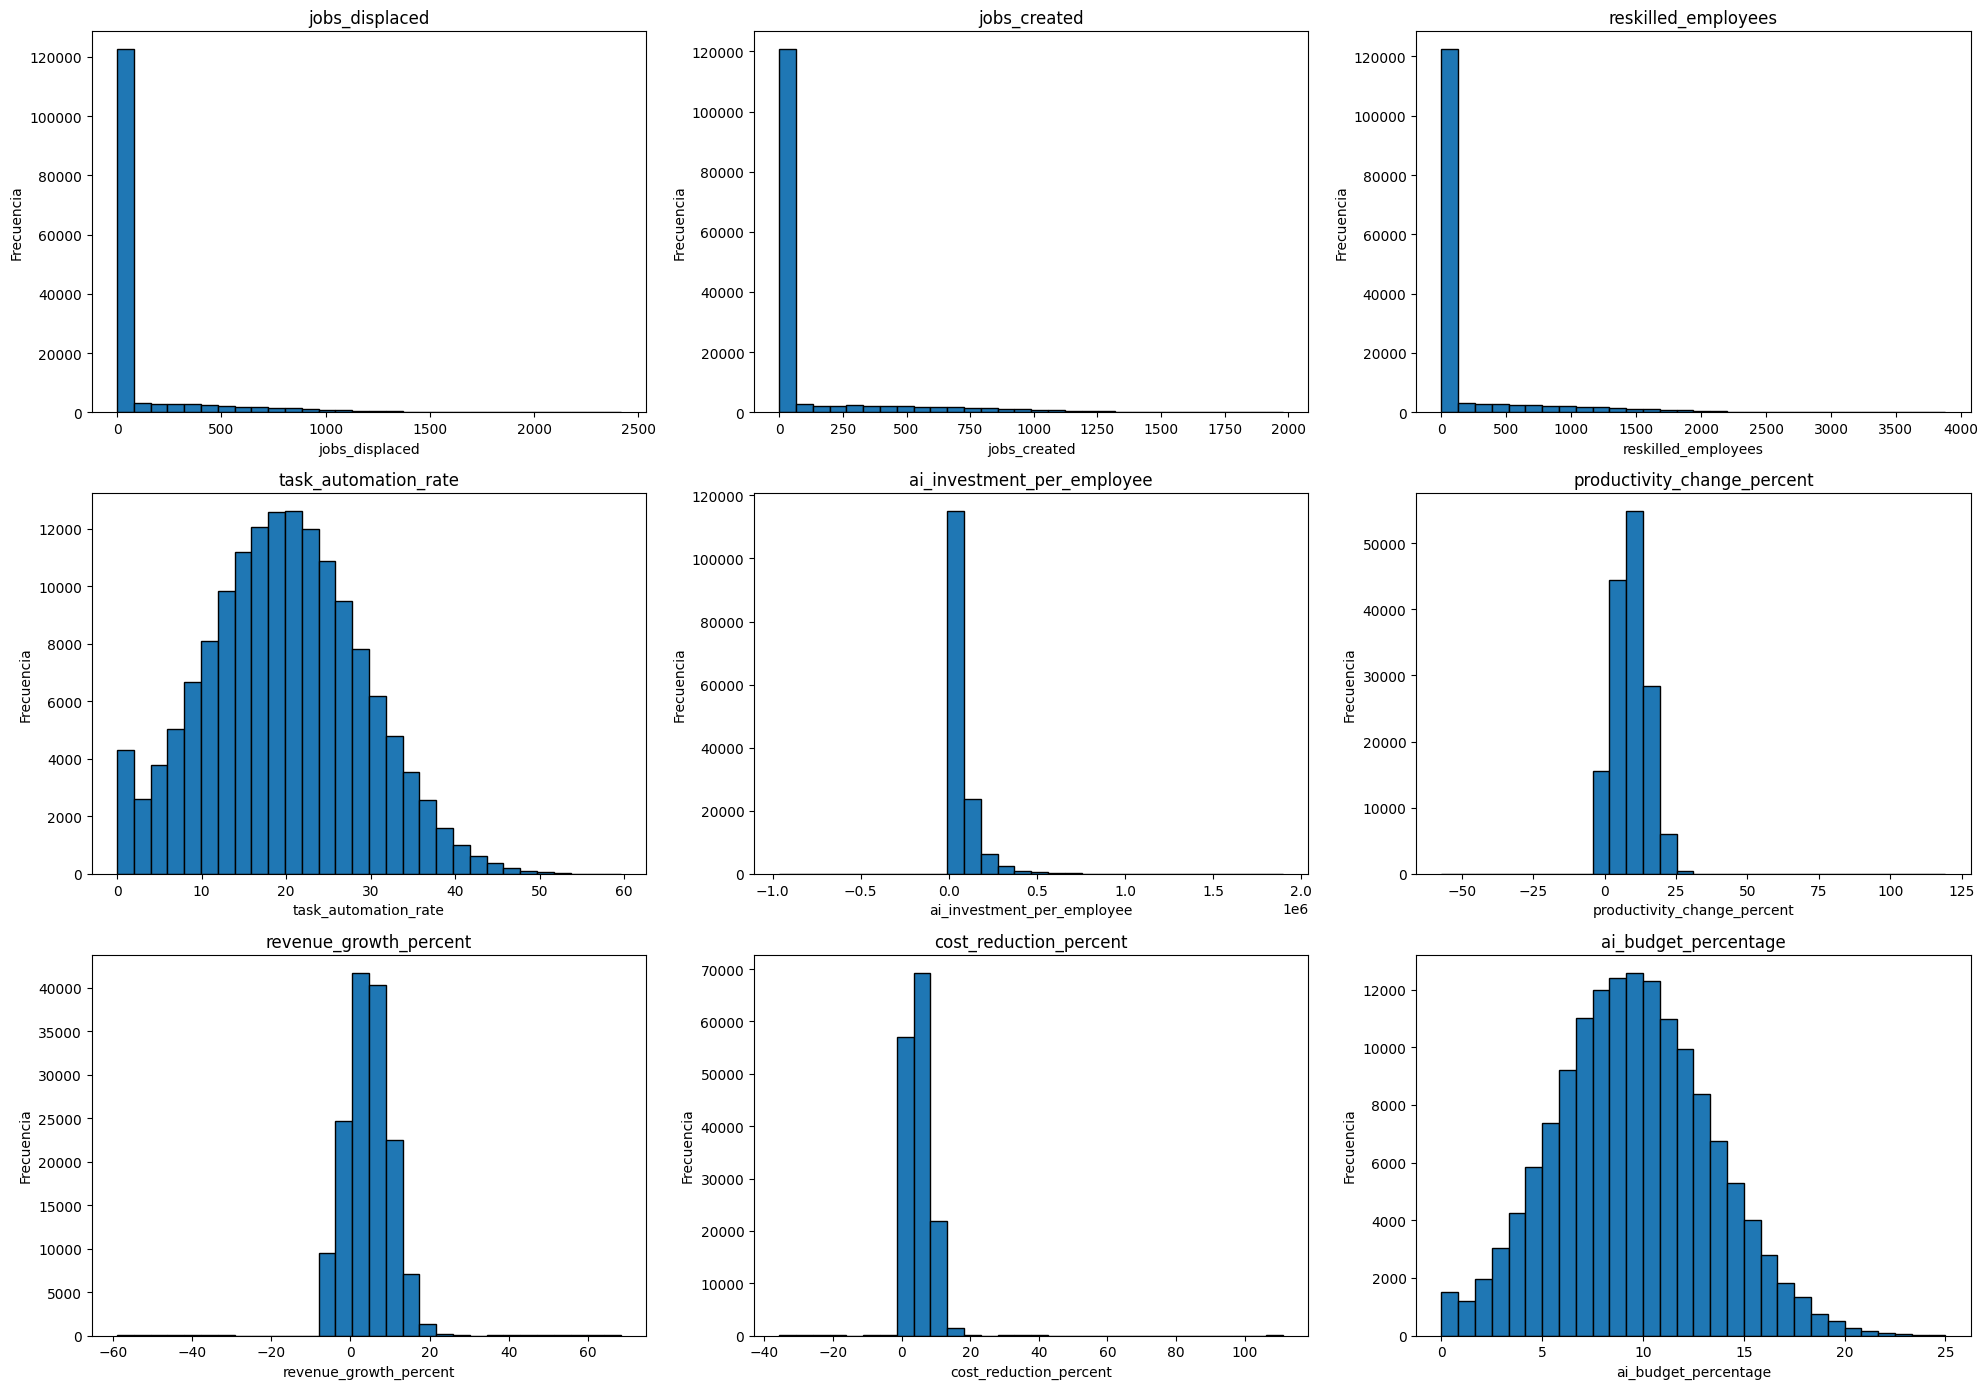

In [11]:
# Graficamos para ver la distribucion de las variables relacionadas a las preguntas de investigacion

variables = ["jobs_displaced", "jobs_created", "reskilled_employees", "task_automation_rate",
             "ai_investment_per_employee", "productivity_change_percent",
             "revenue_growth_percent", "cost_reduction_percent", "ai_budget_percentage"]

fig, axes = plt.subplots(3, 3, figsize=(20, 14))
axes = axes.flatten()

for i, var in enumerate(variables):
    axes[i].hist(df1[var].dropna(), bins=30, edgecolor='black')
    axes[i].set_title(var)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

En varias de estas variables hay una barra inicial tan grande que aplasta el resto del histograma (por ejemplo `jobs_displaced` tiene su rango entre 0 y 2417, así que con 30 bins el primer bin agrupa casi todos los valores "chicos" y no deja ver qué forma tiene la distribución detrás de ese pico). Para las variables con asimetría o curtosis alta, replicamos el histograma, en el caso de las variabels relacionadas con empleo, en todas hay una moda en 0 por lo que excluimos este dato para ver posibles distribuciones escondidas.
Para las variables de productividad e inversion recortamos los ouliters para observar posibles distribuciones escondidas.

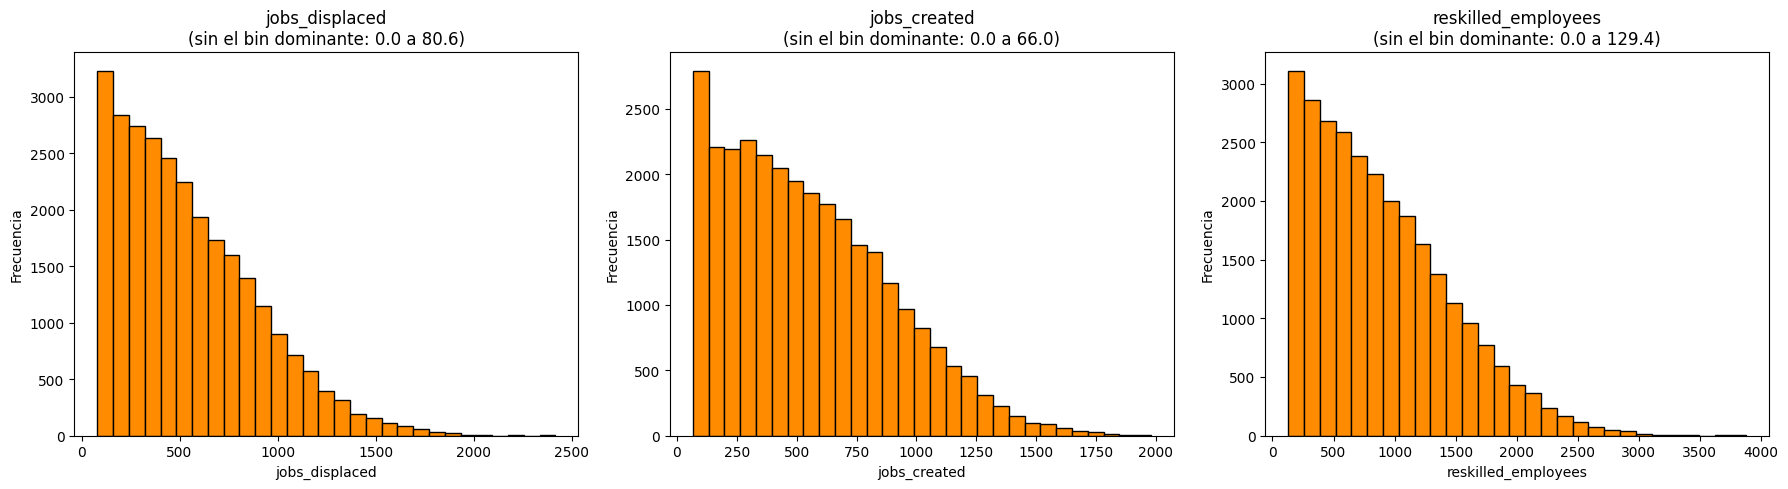

In [12]:
# Variables de empleo: quitamos el bin de la moda para revisar si hay
# una distribucion escondida detras del pico dominante

variables_jobs = ["jobs_displaced", "jobs_created", "reskilled_employees"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for i, var in enumerate(variables_jobs):
    data = df1[var].dropna()
    counts, bin_edges = np.histogram(data, bins=30)

    centros = (bin_edges[:-1] + bin_edges[1:]) / 2
    ancho = bin_edges[1] - bin_edges[0]

    bin_moda = counts.argmax()
    mask = np.ones(len(counts), dtype=bool)
    mask[bin_moda] = False

    axes[i].bar(centros[mask], counts[mask], width=ancho, edgecolor="black", color="darkorange")
    axes[i].set_title(f"{var}\n(sin el bin dominante: {bin_edges[bin_moda]:.1f} a {bin_edges[bin_moda+1]:.1f})")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

Al sacar el primer bin aparece información que la vista completa escondía: `jobs_displaced`, `jobs_created` y `reskilled_employees` no son simplemente "todo cerca de cero con una cola larga" — dentro de ese resto hay una forma decreciente pero suave, más parecida a una exponencial que a un grupo de outliers aislados, lo que sugiere que los valores altos son parte legítima del fenómeno (empresas grandes con reestructuraciones importantes) y no errores de carga.

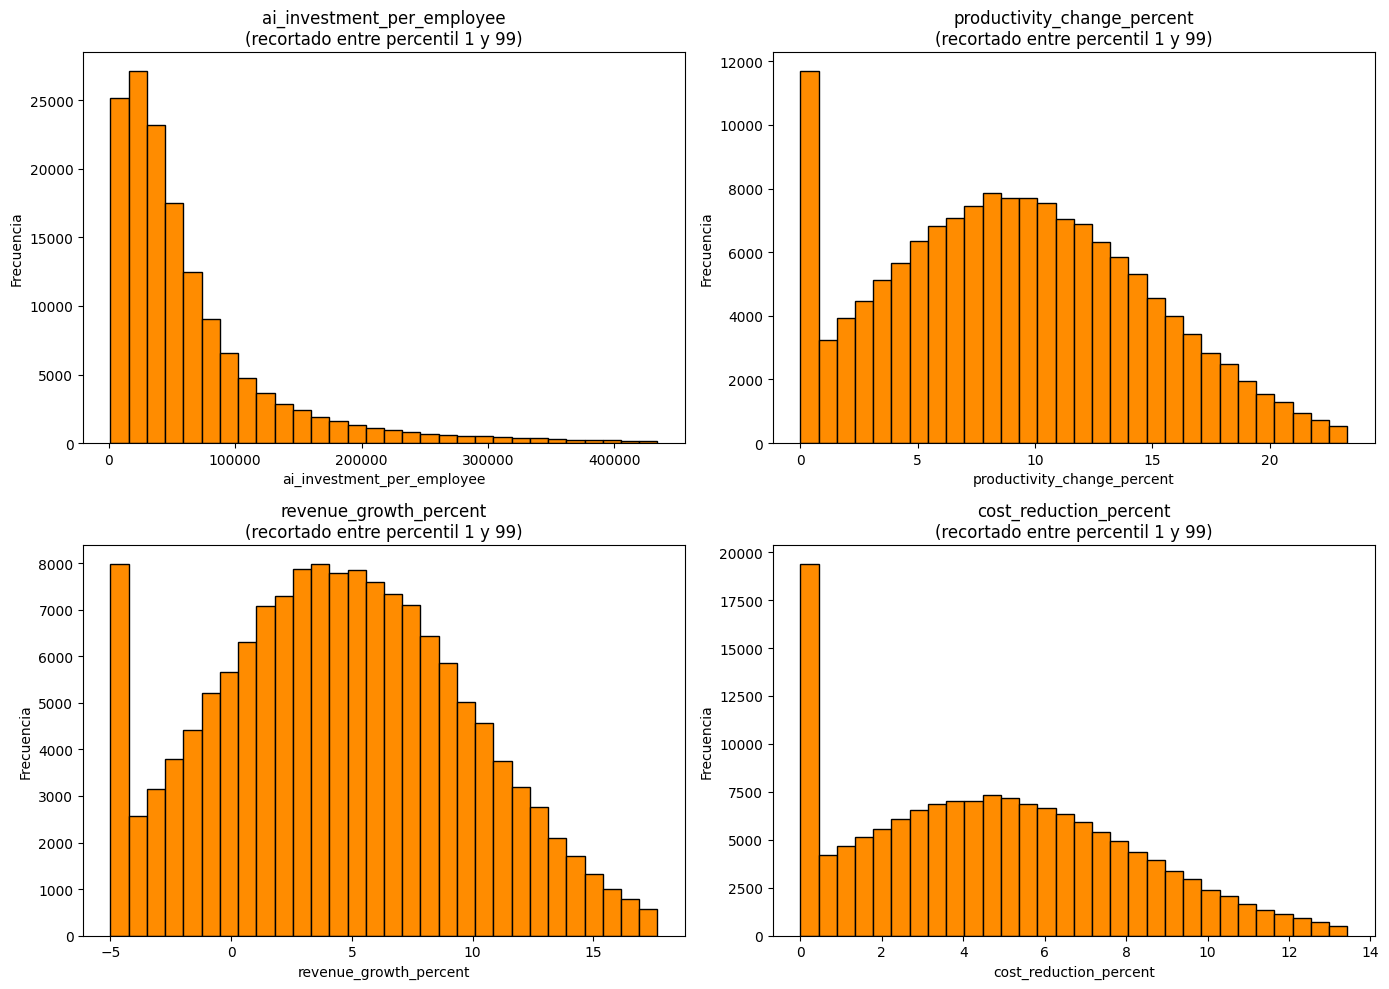

In [13]:
# Variables economicas: recortamos outliers por percentil (1%-99%)
# en vez de sacar un bin, porque aca el problema son colas extremas, no un pico al principio

variables_asimetricas = ["ai_investment_per_employee", "productivity_change_percent",
                          "revenue_growth_percent", "cost_reduction_percent"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(variables_asimetricas):
    data = df1[var].dropna()
    p1, p99 = data.quantile([0.01, 0.99])
    data_recortada = data[(data >= p1) & (data <= p99)]

    axes[i].hist(data_recortada, bins=30, edgecolor="black", color="darkorange")
    axes[i].set_title(f"{var}\n(recortado entre percentil 1 y 99)")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

 En `ai_investment_per_employee`, `revenue_growth_percent` y `cost_reduction_percent`, en cambio, el resto de la distribución sigue mostrando picos aislados y muy separados del cuerpo principal — ahí sí hay indicios de outliers puntuales a revisar antes de modelar, más que una distribución escondida con forma propia.

In [14]:
# Exploramos los estadisticos de las variables

variables = ["jobs_displaced", "jobs_created", "reskilled_employees", "task_automation_rate",
             "ai_investment_per_employee", "productivity_change_percent",
             "revenue_growth_percent", "cost_reduction_percent", "ai_budget_percentage"]

resumen = pd.DataFrame({
    "count": df1[variables].count(),
    "nulos": df1[variables].isnull().sum(),
    "media": df1[variables].mean(),
    "mediana": df1[variables].median(),
    "desvio_std": df1[variables].std(),
    "min": df1[variables].min(),
    "max": df1[variables].max(),
    "q1": df1[variables].quantile(0.25),
    "q3": df1[variables].quantile(0.75),
    "asimetria": df1[variables].skew(),
    "curtosis": df1[variables].kurt(),
})

resumen = resumen.round(2)
resumen

,count,nulos,media,mediana,desvio_std,min,max,q1,q3,asimetria,curtosis
jobs_displaced,150025,0,111.37,10.00,255.86,0.00,2417.00,2.00,41.00,3.03,9.63
jobs_created,150025,0,117.88,12.00,261.66,0.00,1980.00,3.00,41.00,2.79,7.64
reskilled_employees,150025,0,181.64,16.00,417.94,0.00,3881.00,3.00,64.00,2.99,9.21
task_automation_rate,150025,0,19.76,19.70,9.22,0.00,59.63,13.36,26.02,0.11,-0.23
ai_investment_per_employee,150025,0,68684.13,43248.25,92802.06,-962812.21,1898315.75,21259.76,81718.90,3.35,35.43
productivity_change_percent,150025,0,9.31,9.06,6.37,-57.05,119.20,5.06,13.13,2.55,43.61
revenue_growth_percent,147778,2247,4.62,4.48,5.74,-58.91,68.32,0.77,8.25,0.26,10.63
cost_reduction_percent,150024,1,4.86,4.62,4.19,-35.69,111.23,2.11,7.13,7.41,180.18
ai_budget_percentage,147775,2250,9.51,9.43,3.84,0.00,25.00,6.88,12.08,0.12,-0.10


Las variables relacionadas al impacto laboral (jobs_displaced, jobs_created, reskilled_employees) muestran un patrón similar: distribuciones fuertemente asimétricas a la derecha (asimetría entre 2.8 y 3.0), con una moda muy marcada en 0 y una cola larga de valores extremos que llega hasta los miles. La media en los tres casos está muy por encima de la mediana (por ejemplo, en jobs_displaced la media es 111.37 contra una mediana de apenas 10), lo que confirma que un grupo reducido de empresas con valores muy altos está inflando el promedio general. Entre las tres, reskilled_employees presenta los valores más elevados de media y mediana, sugiriendo que, al menos en términos absolutos.

task_automation_rate se comporta de forma distinta: su asimetría (0.11) y curtosis (-0.23) cercanas a 0 indican una distribución aproximadamente simétrica, similar a una normal, con un leve exceso de casos en 0 (empresas sin automatización de tareas).

En cuanto a las variables de inversión y retorno, ai_budget_percentage también muestra una distribución cercana a la simetría (asimetría 0.12), mientras que ai_investment_per_employee es la más problemática del grupo: asimetría de 3.35 y curtosis de 35.43, y valor negativos que no tienen un sentido economico claro.

Por último, productivity_change_percent, revenue_growth_percent y especialmente cost_reduction_percent muestran el mismo patrón: una distribución que a simple vista parece cercana a una normal centrada en valores positivos moderados, pero con curtosis extremadamente alta (43.61, 10.63 y 180.18 respectivamente), lo que indica la presencia de outliers muy alejados del centro que comprimen visualmente el grueso de la distribución. El caso de cost_reduction_percent es el más extremo: una curtosis de 180 es un indicador muy fuerte de valores atípicos que deberían tratarse antes de cualquier análisis bivariado o modelado posterior.



## 3. Análisis bivariado y comparaciones

***Contexto por industria***

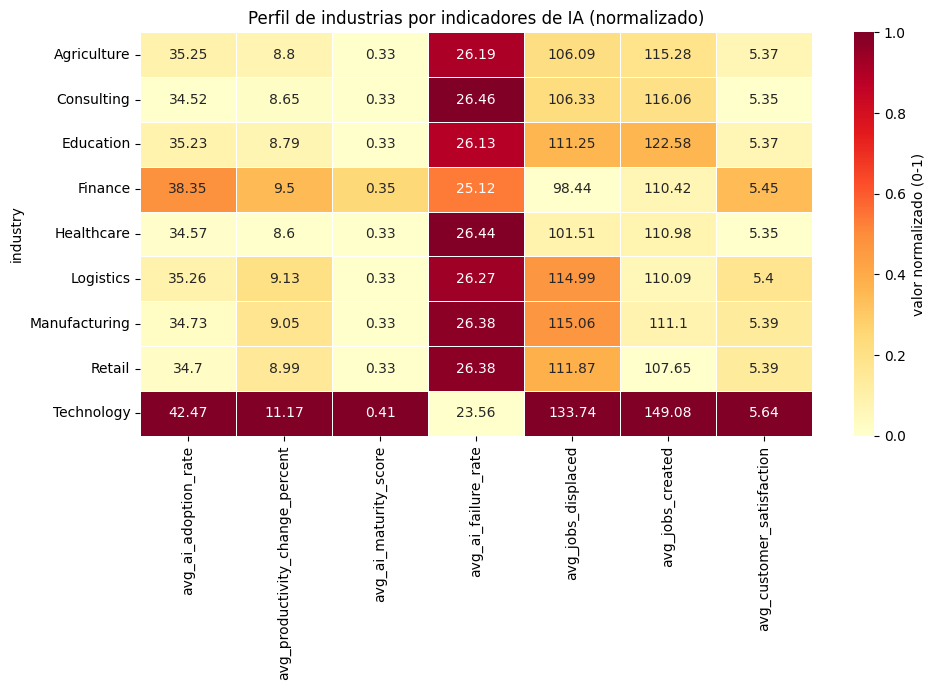

In [15]:
metricas = ["avg_ai_adoption_rate", "avg_productivity_change_percent", "avg_ai_maturity_score",
            "avg_ai_failure_rate", "avg_jobs_displaced", "avg_jobs_created", "avg_customer_satisfaction"]

# Armamos la matriz con industry como índice
heat_data = df2.set_index("industry")[metricas]

# Normalizamos cada columna (0 a 1) para que todas las métricas pesen igual
# pese a tener escalas muy distintas (ej: avg_jobs_displaced ~100 vs avg_ai_maturity_score ~0.3)
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min())

plt.figure(figsize=(10, 7))
sns.heatmap(heat_norm, annot=heat_data.round(2), fmt="", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "valor normalizado (0-1)"})
plt.title("Perfil de industrias por indicadores de IA (normalizado)")
plt.tight_layout()
plt.show()

 Technology se distingue claramente del resto en casi todas las dimensiones, con los valores más altos de adopción de IA (42.47%), cambio en productividad (11.17%), madurez de IA (0.41) y satisfacción del cliente (5.64), además de ser la única industria con avg_ai_failure_rate visiblemente por debajo del resto (23.56 vs. valores entre 25 y 26.5 en las demás). Esto sugiere que, en este dataset, mayor adopción y madurez de IA se asocian con menor tasa de fallas, en vez de con más riesgo operativo.

Las otras ocho industrias muestran un perfil bastante homogéneo entre sí: tasas de adopción similares (34.5%-35.3%, con la excepción de Finance en 38.35%) y tasas de fallas casi idénticas (~26%-26.5%). Donde sí aparece algo de variación es en los indicadores de empleo: Manufacturing y Logistics presentan los avg_jobs_displaced más altos del grupo (115.06 y 114.99), mientras que Finance tiene el más bajo (98.44). En cuanto a creación de empleo, Education se destaca dentro de este grupo homogéneo (122.58), superando incluso a industrias con mayor desplazamiento.

Vale la pena notar que Technology no solo lidera en desplazamiento de empleos (133.74) sino también en creación (149.08), con la diferencia más amplia a favor de la creación entre todas las industrias — un patrón que conviene tener presente al momento de plantear hipótesis sobre destrucción neta de empleo.
Sin embargo hay que tener en cuenta que para las variables de empleos destruidos y creados, la mediana no es el mejor estadistico dada la distribucion asimetrica que presentan estas variables.

***Contexto Geografico***

In [16]:
# --- Fix de nombres de país (SOLO para el mapa de plotly, no toca df3 original) ---
df3_mapa = df3.copy()
df3_mapa["country"] = df3_mapa["country"].replace({"USA": "United States", "UK": "United Kingdom"})

variables_geo = ["gdp_per_capita", "internet_penetration", "digital_maturity_index",
                  "ai_patent_filings_2024", "ai_researchers_per_million"]

titulos = ["PBI per cápita", "Penetración de Internet (%)", "Índice de madurez digital",
           "Patentes de IA (2024)", "Investigadores en IA por millón", "Política de IA"]

orden_politica = {"Lenient": 0, "Moderate": 1, "Strict": 2}
df3_mapa["policy_code"] = df3_mapa["country_ai_policy"].map(orden_politica)   # <-- df3_mapa

fig = make_subplots(
    rows=2, cols=3,
    specs=[[{"type": "choropleth"}]*3, [{"type": "choropleth"}]*3],
    subplot_titles=titulos
)

posiciones = [(1,1), (1,2), (1,3), (2,1), (2,2)]

# --- 5 mapas numéricos, sin barra individual ---
for (var, titulo, pos) in zip(variables_geo, titulos, posiciones):
    choropleth = go.Choropleth(
        locations=df3_mapa["country"],   # <-- df3_mapa
        locationmode="country names",
        z=df3_mapa[var],                 # <-- df3_mapa
        colorscale="YlOrRd",
        showscale=False,
        name=titulo
    )
    fig.add_trace(choropleth, row=pos[0], col=pos[1])

# --- Barra genérica: punto invisible con la misma escala de color, solo para mostrar el gradiente ---
barra_generica = go.Scattergeo(
    lon=[0], lat=[0],
    mode="markers",
    marker=dict(
        size=0.001,
        color=[0.5],
        colorscale="YlOrRd",
        cmin=0, cmax=1,
        showscale=True,
        colorbar=dict(
            title=dict(text="Nivel del<br>indicador", side="top", font=dict(size=11)),
            tickvals=[0, 1],
            ticktext=["Menor", "Mayor"],
            thickness=15,
            len=0.5,
            x=1.03,
            y=0.78
        )
    ),
    showlegend=False,
    hoverinfo="skip"
)
fig.add_trace(barra_generica, row=1, col=1)

# --- 6to mapa: política de IA (categórica), con su propia colorbar ---
choropleth_policy = go.Choropleth(
    locations=df3_mapa["country"],   # <-- df3_mapa
    locationmode="country names",
    z=df3_mapa["policy_code"],       # <-- df3_mapa
    colorscale=[[0, "#a1d99b"], [0.5, "#fdae61"], [1, "#d73027"]],
    zmin=0, zmax=2,
    colorbar=dict(
        title=dict(text="Política de IA", side="top", font=dict(size=11)),
        tickvals=[0, 1, 2],
        ticktext=["Lenient", "Moderate", "Strict"],
        thickness=15,
        len=0.4,
        x=1.03,
        y=0.2
    ),
    showscale=True,
    name="Política de IA"
)
fig.add_trace(choropleth_policy, row=2, col=3)

fig.update_geos(showframe=False, showcoastlines=True, projection_type="natural earth")
fig.update_layout(height=800, width=1500, title_text="Contexto geográfico de indicadores de IA")
fig.show()

Los indicadores de desarrollo digital y capacidad de IA muestran una concentración geográfica clara: Norteamérica, Europa occidental, el este asiático (Japón, Corea del Sur) y Oceanía lideran de forma consistente en PBI per cápita, penetración de internet, índice de madurez digital e investigadores en IA por millón. En el otro extremo, África y gran parte de Asia del sur/sudeste (India, Indonesia, Vietnam, Filipinas) muestran los valores más bajos en casi todas las dimensiones, con Europa del este (Polonia) y Sudamérica ubicadas en un nivel intermedio.

El mapa de patentes de IA (2024) rompe parcialmente este patrón: China se destaca con un volumen de patentes comparable al de Estados Unidos, pese a tener un PBI per cápita considerablemente menor que el resto de los países que lideran las otras métricas. Esto sugiere que la producción de innovación en IA no depende exclusivamente de la riqueza del país, sino que puede estar impulsada por otros factores (política industrial, tamaño de la población, inversión estatal dirigida).

En cuanto a política regulatoria, no se observa una relación directa y simple con el nivel de desarrollo: países con alto desarrollo digital aplican tanto políticas estrictas (Alemania, Países Bajos, Suecia, Japón, Corea del Sur) como moderadas (Estados Unidos, Reino Unido, Canadá, Australia), mientras que las políticas "lenientes" se concentran mayormente en países con menor desarrollo digital (India, Indonesia, Vietnam, Filipinas, Nigeria, Kenia). El caso de China es particularmente notable: combina una política estricta con uno de los niveles más altos de producción de patentes, lo que cuestiona la idea de que mayor regulación necesariamente frena la innovación en IA.

#IMPACTO EN VARIABLES ECONÓMICAS

Una de las premisas de la IA es que vino para mejorar la productividad de las empresas, pero es esto realmente asi? Para intentar responder esta pregunta visualizamos la relacion entre el gasto en IA y variables de productividad, reduccion de costos y crecimiento de ingresos

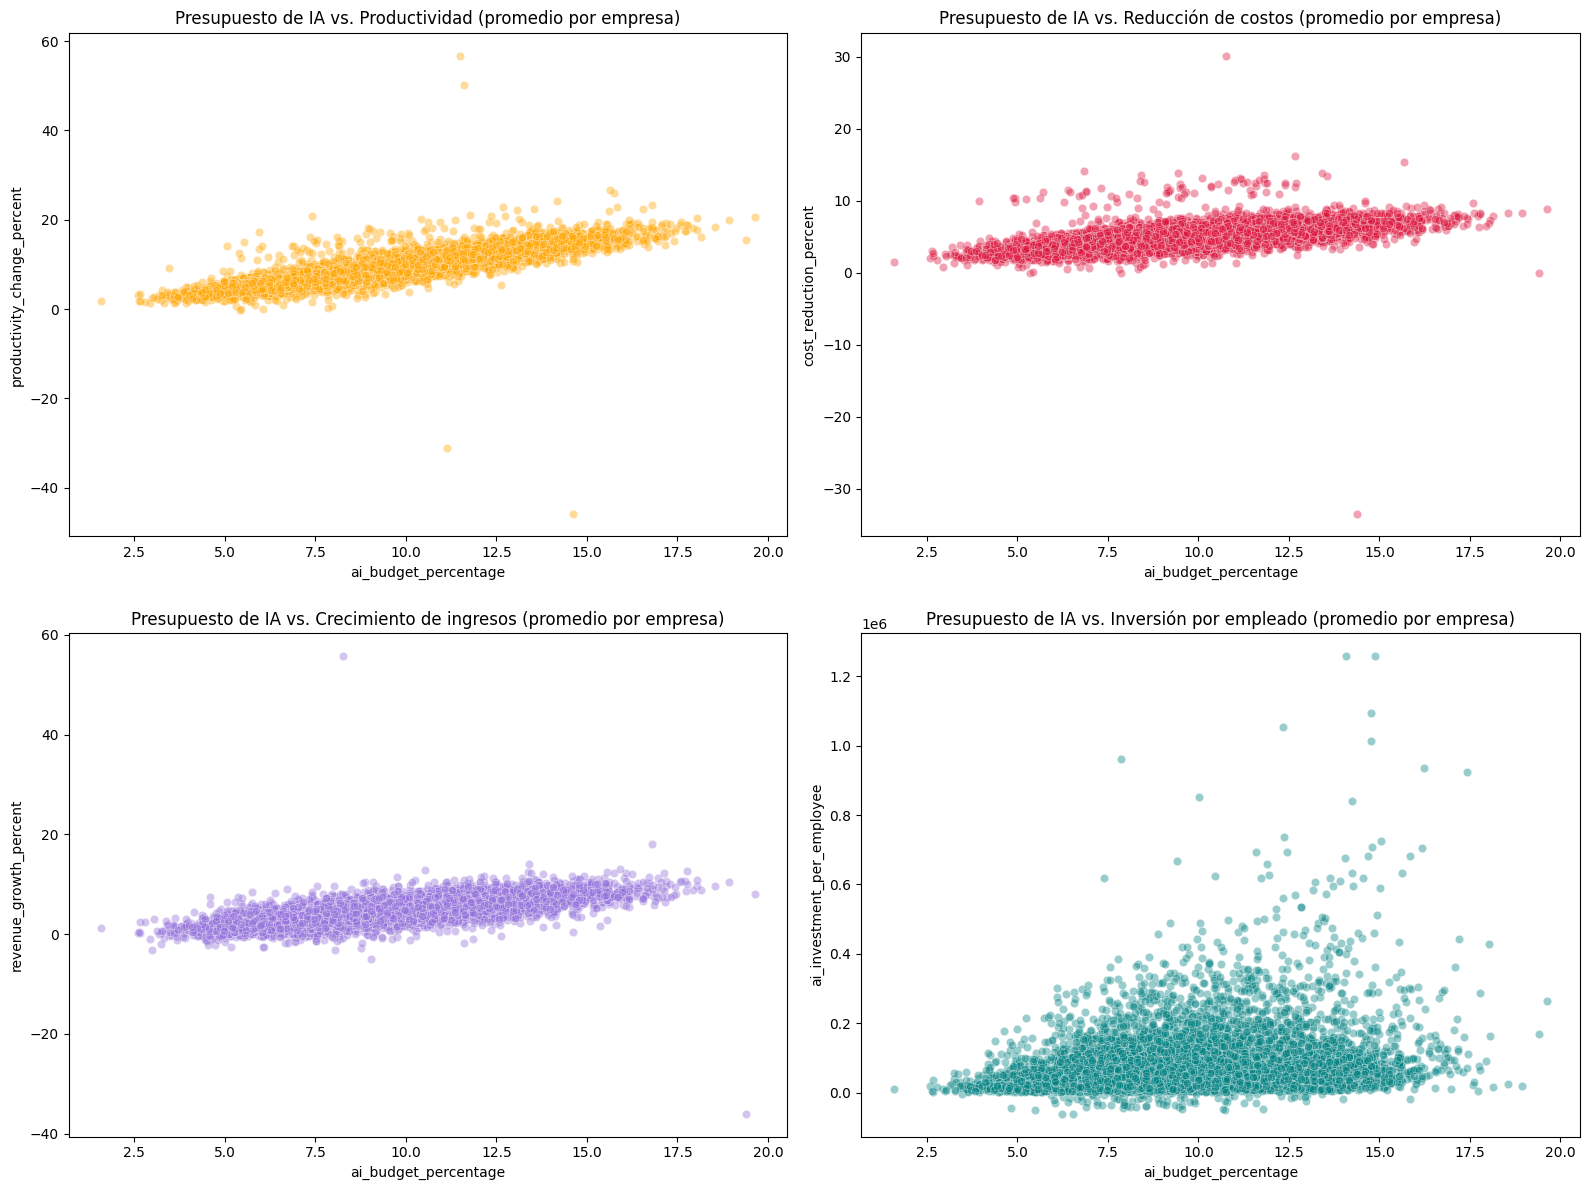

ai_budget_percentage vs productivity_change_percent: 0.838
ai_budget_percentage vs cost_reduction_percent: 0.603
ai_budget_percentage vs revenue_growth_percent: 0.675
ai_budget_percentage vs ai_investment_per_employee: 0.271


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# --- 1. Presupuesto vs Productividad ---
sns.scatterplot(data=df_empresa, x="ai_budget_percentage", y="productivity_change_percent",
                 alpha=0.4, color="orange", ax=axes[0])
axes[0].set_title("Presupuesto de IA vs. Productividad (promedio por empresa)")
axes[0].set_xlabel("ai_budget_percentage")
axes[0].set_ylabel("productivity_change_percent")

# --- 2. Presupuesto vs Reducción de costos ---
sns.scatterplot(data=df_empresa, x="ai_budget_percentage", y="cost_reduction_percent",
                 alpha=0.4, color="crimson", ax=axes[1])
axes[1].set_title("Presupuesto de IA vs. Reducción de costos (promedio por empresa)")
axes[1].set_xlabel("ai_budget_percentage")
axes[1].set_ylabel("cost_reduction_percent")

# --- 3. Presupuesto vs Crecimiento de ingresos ---
sns.scatterplot(data=df_empresa, x="ai_budget_percentage", y="revenue_growth_percent",
                 alpha=0.4, color="mediumpurple", ax=axes[2])
axes[2].set_title("Presupuesto de IA vs. Crecimiento de ingresos (promedio por empresa)")
axes[2].set_xlabel("ai_budget_percentage")
axes[2].set_ylabel("revenue_growth_percent")

# --- 4. Presupuesto vs Inversión por empleado ---
sns.scatterplot(data=df_empresa, x="ai_budget_percentage", y="ai_investment_per_employee",
                 alpha=0.4, color="teal", ax=axes[3])
axes[3].set_title("Presupuesto de IA vs. Inversión por empleado (promedio por empresa)")
axes[3].set_xlabel("ai_budget_percentage")
axes[3].set_ylabel("ai_investment_per_employee")

plt.tight_layout()
plt.show()

# --- Correlaciones de los 4 cruces ---
pares = [
    ("ai_budget_percentage", "productivity_change_percent"),
    ("ai_budget_percentage", "cost_reduction_percent"),
    ("ai_budget_percentage", "revenue_growth_percent"),
    ("ai_budget_percentage", "ai_investment_per_employee"),
]

for x, y in pares:
    corr = df_empresa[[x, y]].corr().iloc[0,1]
    print(f"{x} vs {y}: {corr:.3f}")

El análisis exploratorio muestra una asociación positiva entre el presupuesto destinado a IA y los tres indicadores de retorno considerados: cambio en productividad, reducción de costos y crecimiento de ingresos. Esta relación deberá confirmarse con pruebas estadísticas en instancias posteriores, pero la tendencia visual es consistente en los tres casos. El gasto en ia por empleado y el presupuesto que una empresa destina en gasto para IA no parecen tener una relacion clara.

In [18]:
resumen_industria_4vars = df_empresa.groupby("industry").agg(
    ai_budget_percentage=("ai_budget_percentage", "mean"),
    productivity_change_percent=("productivity_change_percent", "mean"),
    cost_reduction_percent=("cost_reduction_percent", "mean"),
    revenue_growth_percent=("revenue_growth_percent", "mean"),
    ai_investment_per_employee=("ai_investment_per_employee", "mean"),
    n_empresas=("company_id", "count")
).reset_index().sort_values("ai_budget_percentage", ascending=False)

resumen_industria_4vars.round(2)

resumen_industria_4vars.round(2).style.background_gradient(
    cmap="YlOrRd", subset=["ai_budget_percentage", "productivity_change_percent",
                            "cost_reduction_percent", "revenue_growth_percent",
                            "ai_investment_per_employee"]
)

,industry,ai_budget_percentage,productivity_change_percent,cost_reduction_percent,revenue_growth_percent,ai_investment_per_employee,n_empresas
8,Technology,12.200000,11.170000,5.370000,5.580000,86495.660000,1411
3,Finance,9.570000,9.560000,4.890000,4.860000,70321.030000,1346
0,Agriculture,9.050000,8.860000,4.590000,4.370000,65077.300000,1039
2,Education,9.040000,8.870000,4.550000,4.310000,67839.470000,1015
5,Logistics,9.020000,9.160000,5.030000,4.540000,66908.360000,867
6,Manufacturing,8.990000,9.070000,4.920000,4.450000,63271.250000,1172
4,Healthcare,8.940000,8.630000,4.620000,4.230000,66247.080000,1243
1,Consulting,8.930000,8.700000,4.540000,4.330000,62417.460000,834
7,Retail,8.930000,9.050000,5.040000,4.500000,63726.680000,1095


A nivel industria, el sector tecnológico lidera de forma clara en las tres métricas de retorno, seguido a cierta distancia por el sector financiero. La única excepción parcial aparece en reducción de costos, donde logística, retail y manufactura se acercan más al desempeño de Technology que en las otras dos métricas, aunque sin superarlo.

In [19]:


# --- Agregamos por país las 4 variables ---
resumen_pais_4vars = df_empresa.groupby("country").agg(
    productivity_change_percent=("productivity_change_percent", "mean"),
    cost_reduction_percent=("cost_reduction_percent", "mean"),
    revenue_growth_percent=("revenue_growth_percent", "mean"),
    ai_investment_per_employee=("ai_investment_per_employee", "mean"),
    n_empresas=("company_id", "count")
).reset_index()

# --- Fix de nombres de país ---
resumen_pais_4vars["country"] = resumen_pais_4vars["country"].replace(
    {"USA": "United States", "UK": "United Kingdom"}
)

variables_mapa = ["productivity_change_percent", "cost_reduction_percent",
                   "revenue_growth_percent", "ai_investment_per_employee"]

titulos = ["Cambio en productividad", "Reducción de costos",
           "Crecimiento de ingresos", "Inversión en IA por empleado"]

# --- Armado de la grilla 2x2 ---
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "choropleth"}, {"type": "choropleth"}],
           [{"type": "choropleth"}, {"type": "choropleth"}]],
    subplot_titles=titulos
)

posiciones = [(1,1), (1,2), (2,1), (2,2)]

for (var, titulo, pos) in zip(variables_mapa, titulos, posiciones):
    choropleth = go.Choropleth(
        locations=resumen_pais_4vars["country"],
        locationmode="country names",
        z=resumen_pais_4vars[var],
        colorscale="YlOrRd",
        showscale=False,
        name=titulo
    )
    fig.add_trace(choropleth, row=pos[0], col=pos[1])

fig.update_geos(showframe=False, showcoastlines=True, projection_type="natural earth")
fig.update_layout(height=800, width=1400, title_text="Indicadores económicos de IA por país (agregado por empresa)")
fig.show()

A nivel geográfico, se observa una tendencia predominante donde los países con mayor PBI per cápita obtienen mejores resultados en productividad, reducción de costos y crecimiento de ingresos — replicando el patrón ya identificado en el contexto general de desarrollo digital. La excepción más notable es India, que muestra la inversión en IA por empleado más alta pese a no liderar en productividad ni en las demás métricas de retorno. Esta observación amerita revisión adicional, dado que la variable de inversión por empleado todavía contiene valores atípicos sin depurar (incluyendo montos negativos) y no se verificó si el resultado se sostiene con una muestra suficiente de empresas para ese país.

IMPACTO EN LA FUERZA LABORAL


Con la llegada de la IA a las empresas, uno de los mayores miedos es que esta desplace y destruya muchos empleos. Para comprobar si los miedos infundados contra la IA y la destrucción de empleos son reales, graficamos variables relacionadas a la creacion, destruccion  de empleos, tasas de automatizacion y re capacitacion de empleados.

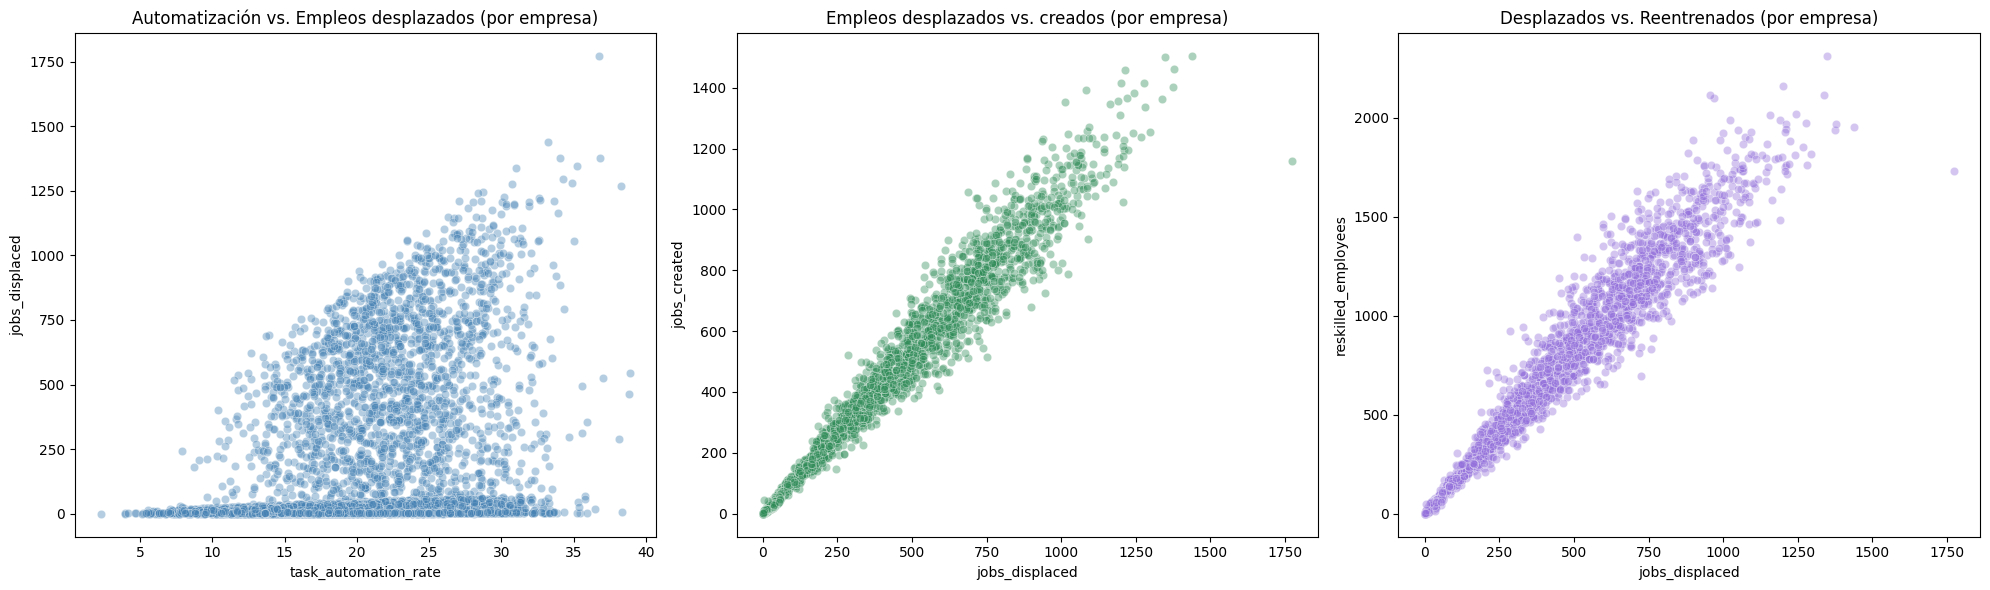

task_automation_rate vs jobs_displaced: encuesta=0.286 | empresa=0.317
jobs_displaced vs jobs_created: encuesta=0.924 | empresa=0.991
jobs_displaced vs reskilled_employees: encuesta=0.877 | empresa=0.988


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.scatterplot(data=df_empresa, x="task_automation_rate", y="jobs_displaced",
                 alpha=0.4, color="steelblue", ax=axes[0])
axes[0].set_title("Automatización vs. Empleos desplazados (por empresa)")

sns.scatterplot(data=df_empresa, x="jobs_displaced", y="jobs_created",
                 alpha=0.4, color="seagreen", ax=axes[1])
axes[1].set_title("Empleos desplazados vs. creados (por empresa)")

sns.scatterplot(data=df_empresa, x="jobs_displaced", y="reskilled_employees",
                 alpha=0.4, color="mediumpurple", ax=axes[2])
axes[2].set_title("Desplazados vs. Reentrenados (por empresa)")

plt.tight_layout()
plt.show()

# --- Comparación de correlaciones: encuesta vs. empresa ---
pares = [
    ("task_automation_rate", "jobs_displaced"),
    ("jobs_displaced", "jobs_created"),
    ("jobs_displaced", "reskilled_employees"),
]

for x, y in pares:
    corr_original = df1[[x, y]].corr().iloc[0,1]
    corr_agregado = df_empresa[[x, y]].corr().iloc[0,1]
    print(f"{x} vs {y}: encuesta={corr_original:.3f} | empresa={corr_agregado:.3f}")

A simple vista se ve un patron muy claro. Las empresas parecen destruir empleos al mismo ritmo que crean nuevos empleos. Tambien hay una asociacion positiva fuerte entre los empleos desplazados y los empleados re capacitados.Sin embargo debemos tener en cuenta que estas variables son numeros absolutos, lo correcto seria analizar tasas de destruccion/creacion de empleos por cantidad de empleados, para asi independizarnos del tamaño de la empresa. La relacion entre la tasa de automatizacion y el desplazamiento de empleos no es tan clara y merece un analisis mas exhaustivo antes de sacar conclusiones.

In [21]:
resumen_industria_empleo = df_empresa.groupby("industry").agg(
    jobs_displaced=("jobs_displaced", "mean"),
    jobs_created=("jobs_created", "mean"),
    reskilled_employees=("reskilled_employees", "mean"),
    jobs_net_balance=("jobs_net_balance", "mean"),
    task_automation_rate=("task_automation_rate", "mean"),
    n_empresas=("company_id", "count")
).reset_index().sort_values("jobs_net_balance", ascending=False)



resumen_industria_empleo.round(2)

resumen_industria_empleo.round(2).style.background_gradient(
    cmap="YlGnBu", subset=["jobs_displaced", "jobs_created", "reskilled_employees",
                            "jobs_net_balance", "task_automation_rate"]
)

,industry,jobs_displaced,jobs_created,reskilled_employees,jobs_net_balance,task_automation_rate,n_empresas
8,Technology,134.800000,149.740000,224.580000,14.940000,21.600000,1411
3,Finance,99.430000,111.460000,171.160000,12.030000,19.690000,1346
2,Education,111.310000,122.850000,192.830000,11.540000,18.180000,1015
1,Consulting,106.040000,115.750000,180.660000,9.710000,18.060000,834
4,Healthcare,101.500000,110.890000,171.420000,9.380000,18.100000,1243
0,Agriculture,106.200000,115.480000,177.910000,9.280000,18.370000,1039
6,Manufacturing,115.050000,111.120000,172.680000,-3.920000,21.050000,1172
7,Retail,111.350000,107.200000,167.430000,-4.160000,21.030000,1095
5,Logistics,114.720000,109.730000,168.290000,-4.980000,21.240000,867


Si bien Technology vuelve a liderar en saldo neto de empleo (14.94) y en cantidad de empleados reentrenados (224.58, notablemente por encima del resto), no es la única industria con resultado favorable: Finance, Education, Consulting, Healthcare y Agriculture también muestran saldo neto positivo, formando un grupo de industrias más orientadas a servicios y conocimiento. En contraste, Manufacturing, Retail y Logistics son las únicas con saldo neto negativo, pese a tener tasas de automatización similares o incluso superiores a algunas del primer grupo.

In [22]:
# Analizamos el contexto geografico para ver si influye de alguna manera en como se comportan estas variables

resumen_pais_empleo = df_empresa.groupby("country").agg(
    jobs_displaced=("jobs_displaced", "mean"),
    jobs_created=("jobs_created", "mean"),
    reskilled_employees=("reskilled_employees", "mean"),
    jobs_net_balance=("jobs_net_balance", "mean"),
    task_automation_rate=("task_automation_rate", "mean"),
    n_empresas=("company_id", "count")
).reset_index()

resumen_pais_empleo["country"] = resumen_pais_empleo["country"].replace(
    {"USA": "United States", "UK": "United Kingdom"}
)

variables_mapa = ["jobs_displaced", "jobs_created", "reskilled_employees",
                   "jobs_net_balance", "task_automation_rate"]
titulos = ["Empleos desplazados", "Empleos creados", "Empleados reentrenados",
           "Saldo neto de empleo", "Tasa de automatización"]

fig = make_subplots(
    rows=2, cols=3,
    specs=[[{"type": "choropleth"}]*3, [{"type": "choropleth"}]*3],
    subplot_titles=titulos
)

posiciones = [(1,1), (1,2), (1,3), (2,1), (2,2)]

for (var, titulo, pos) in zip(variables_mapa, titulos, posiciones):
    choropleth = go.Choropleth(
        locations=resumen_pais_empleo["country"],
        locationmode="country names",
        z=resumen_pais_empleo[var],
        colorscale="YlGnBu",
        showscale=False,
        name=titulo
    )
    fig.add_trace(choropleth, row=pos[0], col=pos[1])

# --- Barra genérica: punto invisible con la misma escala de color, solo para mostrar el gradiente ---
barra_generica = go.Scattergeo(
    lon=[0], lat=[0],
    mode="markers",
    marker=dict(
        size=0.001,
        color=[0.5],
        colorscale="YlGnBu",
        cmin=0, cmax=1,
        showscale=True,
        colorbar=dict(
            title=dict(text="Nivel del<br>indicador", side="top", font=dict(size=11)),
            tickvals=[0, 1],
            ticktext=["Menor", "Mayor"],
            thickness=15,
            len=0.5,
            x=1.02,
            y=0.2   # a la altura de la fila 2, aprovechando el espacio vacío de esa fila
        )
    ),
    showlegend=False,
    hoverinfo="skip"
)
fig.add_trace(barra_generica, row=2, col=2)

fig.update_geos(showframe=False, showcoastlines=True, projection_type="natural earth")
fig.update_layout(height=800, width=1400, title_text="Indicadores de empleo por país (agregado por empresa)")
fig.show()

  A nivel geográfico, los mapas muestran patrones similares a los observados en el contexto de desarrollo digital general, con Norteamérica, Europa occidental y Oceanía destacándose en la mayoría de los indicadores. Es importante señalar, sin embargo, que las variables de empleo utilizadas aquí son conteos absolutos (cantidad de personas) y no están normalizadas por el tamaño promedio de empresa en cada país, por lo que las diferencias observadas entre países podrían reflejar en parte variaciones en la composición de la muestra (empresas más grandes en algunos países) más que diferencias reales en la intensidad del impacto de la IA sobre el empleo. Esta limitación queda anotada como punto a resolver en instancias posteriores del análisis, normalizando estas variables por num_employees antes de comparar entre países.

##Hipótesis de investigación a partir de la exploración anterior formulamos
##dos preguntas concretas, con una dirección técnica clara para abordarlas en los próximos prácticos.

### Hipótesis 1: ¿Es posible predecir el crecimiento de ingresos de una empresa a partir de su inversión en IA?**Qué observamos:** en el análisis por empresa (`df_empresa`) encontramos una asociación positiva entre `ai_budget_percentage` y los tres indicadores de retorno (productividad, reducción de costos, crecimiento de ingresos), y Technology lidera de forma consistente en las tres métricas. Sin embargo, también vimos casos como India, que tiene la inversión por empleado más alta sin liderar en productividad — lo que sugiere que la relación no es simplemente lineal ni universal.**Cómo la abordaríamos técnicamente:** entrenar un modelo de regresión (empezando por regresión lineal múltiple, y comparando contra modelos no lineales como Random Forest o Gradient Boosting) que prediga `revenue_growth_percent` a partir de `ai_budget_percentage`, `ai_investment_per_employee` y características estructurales de la empresa (`industry`, `company_size`, `num_employees`). Antes de modelar, hay que depurar `ai_investment_per_employee` (tiene valores negativos sin sentido económico) y evaluar si conviene construir un índice compuesto de retorno (productividad + reducción de costos + crecimiento de ingresos) en lugar de predecir cada métrica por separado.

### Hipótesis 2: ¿Se puede predecir el saldo neto de empleo (creado - desplazado) a partir de la tasa de adopción de IA y las características de la empresa?**Qué observamos:** a nivel industria, Technology tiene simultáneamente el mayor desplazamiento y la mayor creación de empleo, con saldo neto positivo, mientras que Manufacturing, Retail y Logistics muestran saldo neto negativo pese a tener tasas de automatización similares o incluso mayores que industrias con saldo positivo. Esta disociación entre automatización y resultado neto (una relación tipo "cono", donde la automatización habilita pero no determina el desplazamiento) sugiere que el *tipo* de tareas automatizadas importa más que el *volumen* de automatización.**Cómo la abordaríamos técnicamente:** primero normalizar `jobs_displaced`, `jobs_created` y `reskilled_employees` por `num_employees` (son conteos absolutos y hoy están sesgados por el tamaño de la empresa), y calcular una tasa de saldo neto por trabajador. Después, entrenar un modelo de clasificación o regresión (según cómo se termine definiendo la variable objetivo) usando `task_automation_rate`, `ai_adoption_stage`, `industry`, `company_size` y `ai_use_case` como predictores, para evaluar si el tipo de caso de uso de IA (`ai_use_case`) tiene más poder predictivo sobre el saldo neto que la tasa de automatización en sí.

##INTEGRACION DE ARCHIVOS

Unimos df1 con df2 y df3 usando las columnas que tienen en común: industry para pegar el contexto de industria (df2) y country para pegar el contexto de país (df3). Antes de unir, descartamos la columna region de df3, porque ya está presente en df1 con los mismos valores para cada país (lo verificamos explícitamente: coincide en las 30 empresas/países, sin discrepancias) — mergearla tal cual hubiera generado una columna duplicada (region_x/region_y) sin aportar información nueva.

Ambas uniones se hicieron con left join, tomando df1 como tabla base, para no perder ninguna fila aunque no encuentre correspondencia en df2 o df3. Además usamos validate="m:1", que obliga a que industry y country sean claves únicas del lado de df2/df3 — si no lo fueran, el merge tira un error en vez de multiplicar filas de df1 sin que nos demos cuenta.

El resultado (df_final) conserva la misma cantidad de filas que df1, con las columnas de df2 y df3 agregadas al final. Las filas que no tenían industry o country cargada en df1 quedan con NaN en las columnas correspondientes de contexto, ya que no hay con qué buscar la correspondencia — ese faltante se resuelve en la etapa siguiente (tratamiento de valores faltantes), completando primero industry/country a partir de otros trimestres de la misma empresa antes de rehacer esta unión, para maximizar la cantidad de filas con contexto completo.

In [23]:
# Union de df1 con df2 (por industry) y df3 (por country)

# df3 tiene 'region', que ya esta en df1 con los mismos valores (verificado
# consistente para los 30 paises) -> la sacamos para no duplicar la columna
df3_sin_region = df3.drop(columns=["region"])

df_final = df1.merge(df2, on="industry", how="left", validate="m:1")
df_final = df_final.merge(df3_sin_region, on="country", how="left", validate="m:1")

print(f"Shape df1 original: {df1.shape}")
print(f"Shape df_final: {df_final.shape}")
print(f"Filas sin match en df2 (industry nula): {df_final['avg_ai_adoption_rate'].isnull().sum()}")
print(f"Filas sin match en df3 (country nula): {df_final['gdp_per_capita'].isnull().sum()}")

Shape df1 original: (150025, 44)
Shape df_final: (150025, 57)
Filas sin match en df2 (industry nula): 2253
Filas sin match en df3 (country nula): 1


##VALORES FALTANTES

Inspeccionamos para ver cuantos y que proporcion de nulos hay en cada variable

In [24]:
# Cantidad y proporción de nulos por variable en df_final
nulos = df_final.isnull().sum()
proporcion = (nulos / len(df_final) * 100).round(2)

resumen_nulos = pd.DataFrame({
    "n_nulos": nulos,
    "%_nulos": proporcion
})

# Mostramos solo las que tienen al menos un nulo, ordenadas de mayor a menor
resumen_nulos = resumen_nulos[resumen_nulos["n_nulos"] > 0].sort_values("%_nulos", ascending=False)
resumen_nulos

,n_nulos,%_nulos
industry,2253,1.5
ai_adoption_rate,2249,1.5
annual_revenue_usd_millions,2247,1.5
company_size,2251,1.5
ai_training_hours,2249,1.5
ai_budget_percentage,2250,1.5
data_privacy_level,2252,1.5
ai_primary_tool,2252,1.5
avg_jobs_created,2253,1.5
avg_jobs_displaced,2253,1.5


#Tratamiento de variables categoricas fijas

Primero chequeamos cuales son las variables que deberian mantenerse fijas a lo largo de todo el periodo de encuestas

In [25]:
# Candidatas a "fijas" (no deberían variar entre quarters de la misma empresa)
candidatas_fijas = ["industry", "country", "region", "company_size",
                     "company_age_group", "data_privacy_level",
                     "ai_ethics_committee", "ai_primary_tool"]

n_empresas = df_final["company_id"].nunique()

for col in candidatas_fijas:
    valores_distintos = df_final.groupby("company_id")[col].nunique()
    inestables = (valores_distintos > 1).sum()
    print(f"{col:25s} -> {inestables} empresas con más de 1 valor distinto (de {n_empresas})")

industry                  -> 0 empresas con más de 1 valor distinto (de 10025)
country                   -> 0 empresas con más de 1 valor distinto (de 10025)
region                    -> 0 empresas con más de 1 valor distinto (de 10025)
company_size              -> 0 empresas con más de 1 valor distinto (de 10025)
company_age_group         -> 2759 empresas con más de 1 valor distinto (de 10025)
data_privacy_level        -> 9999 empresas con más de 1 valor distinto (de 10025)
ai_ethics_committee       -> 9990 empresas con más de 1 valor distinto (de 10025)
ai_primary_tool           -> 10000 empresas con más de 1 valor distinto (de 10025)


Completamos las variables categoricas fijas que tienen nulos

In [29]:
fijas = ["industry", "country", "region", "company_size"]
for col in fijas:
    df_final[col] = df_final.groupby("company_id")[col].transform(lambda s: s.ffill().bfill())

/tmp/ipykernel_600/697177189.py:3: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipykernel_600/697177189.py:3: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipykernel_600/697177189.py:3: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipykernel_600/697177189.py:3: FutureWarning:

Downcasting object dtype arrays on .fillna, .f

verificamos cuantos nulos quedan despues del tratamiento

In [30]:
nulos = df_final.isnull().sum()
proporcion = (nulos / len(df_final) * 100).round(2)

resumen_nulos = pd.DataFrame({
    "n_nulos": nulos,
    "%_nulos": proporcion
})

resumen_nulos = resumen_nulos[resumen_nulos["n_nulos"] > 0].sort_values("%_nulos", ascending=False)
resumen_nulos

,n_nulos,%_nulos
ai_adoption_rate,2249,1.5
annual_revenue_usd_millions,2247,1.5
revenue_growth_percent,2247,1.5
employee_satisfaction_score,2247,1.5
ai_training_hours,2249,1.5
ai_budget_percentage,2250,1.5
data_privacy_level,2252,1.5
ai_primary_tool,2252,1.5
avg_jobs_created,2253,1.5
avg_jobs_displaced,2253,1.5
